### Measurement
Measurement begins with recording the ISSW-measured intensity of light when a filter paper contains LAI (for *light-absorbing impurity*), and $I_0$ when a filter is clean (see Eq. 1 of Grenfell et al, 2011, Eq. 1). Then the *absorption optical depth* is given by

$$
\chi_\lambda = log({I_0 \over I}) \ \ \ (1)
$$

where Here, we'll focus on $\lambda_1=450 \ nm$ and $\lambda_2=600 \ nm$). We can use the absorption optical depth to compute an *instrumental optical depth*, $f_{instr}$, according to a version (the inverse) of Grenfell et al's Eq. 4,

$$
f_{instr}(R_\lambda,\chi_\lambda) = {1\over2}ln \bigl( (1-R_\lambda) \times exp(\chi_\lambda)+((1-R_\lambda)^2 \times exp(2\chi_\lambda)+4R_\lambda) \bigr) \ \ \ (2)
$$

where $R_\lambda \equiv R_1R_2(\lambda)$ is the wavelength-dependent product of reflectivities of the two integrating spheres of the ISSW; other instrument-specific parameters are the size of the ISSW aperture and the intensity of the light source. Properties of the millipore filter paper itself also affect $f_{instr}$. We account for these effects via the factor $\kappa_\lambda$,

$$
\tau_\lambda  = f_{instr} \times \kappa_\lambda \ \ \ (3)
$$

Values of $\kappa_\lambda$ and $R_\lambda$ must be determined by a calibration procedure (described below). Once known, however, we can compute the LAI loading, 

$$
L_{ISSW} = {\tau_\lambda \over \beta_{\lambda,std}}  \ \ \ (4)
$$

where $\beta_{\lambda,std}$ is the *mass absorption cross section*, also referred to as *MAC*, of a standard LAI. For a fullerene standard, these values are $\beta_{450,fullerene}=8.9 \ m^2/g$ and $\beta_{600,fullerene}=6.5 \ m^2/g$, consistent with $Å=1.09$. We can also use ratios of optical depths produced by Eq. 3 to calculate an LAI's's *absorption Angstrom exponent*,

$$
Å = -{log(\tau_{450}/\tau_{600}) \over log(\lambda_{450}/\lambda_{600})} \ \ \ (5)
$$

where (because of the proportionality in Eq. 3) we could also use $-{log(\tau'_{450}/\tau'_{600}) \over log(\lambda_{450}/\lambda_{600})}$ to achieve the same result.

### Calibration
The goal of calibration is to obtain values of $R_{450}$, $R_{600}$, $\kappa_{450}$ and $\kappa_{600}$. The process relies on ISSW-measured intensities ($I$) of a set of filter papers with varying loadings ($L_{ISSW}$) of a standard LAI (fullerene) ... that minimize the sum of squared differences between $\tau_\lambda$(obs) and $\tau_\lambda$(theory). We'll need the inverse of Eq. 2 (which is Grenfell et al's Eq. 4),

$$
\chi_\lambda = 2 f_\lambda + ln \bigl ({1 - R e^{-4 f_\lambda}   \over 1 - R}    \bigr ) \ \ \ (6)
$$

... We should note that this procedure also takes into account a difference in units, namely, that $L_{ISSW}$ has units ${\mu g \over cm^2}$, while $L_{LAHM}$ has units $\mu g$.


**References**

Grenfell, T. C., Doherty, S. J., Clarke, A. D., & Warren, S. G. (2011). Light absorption from particulate impurities in snow and ice determined by spectrophotometric analysis of filters. Applied Optics, 50(14), 2037-2048.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from importlib import reload  # Python 3.4+
import ISSWlib as IS; reload(IS)
%matplotlib inline

### Fullerene standard on millipore filters

In [2]:
# Load the standard ISSW spectra
spectrum_folder = 'Ulyana ful/'
filtertype_std = 'millipore'
spectrum_filelist = spectrum_folder+'spectrum_files.txt'
spectrum_list, number_of_loadings = IS.get_spectrum_list(spectrum_filelist)

From getline0list: In  Ulyana ful/spectrum_files.txt , finding these spectra:
      2 ug.txt
      5 ug.txt
      10 ug.txt
      25 ug.txt
      40 ug.txt
      66 ug.txt


lambda_450 =  450.0
lambda_600 =  600.0
[0.36342949 0.74688788 1.4248183  1.80884811 1.9800604 ]
[0.29156555 0.73696378 1.52024991 2.75499862 3.57853571]
Length of L_range =  5
Number of loadings =  5


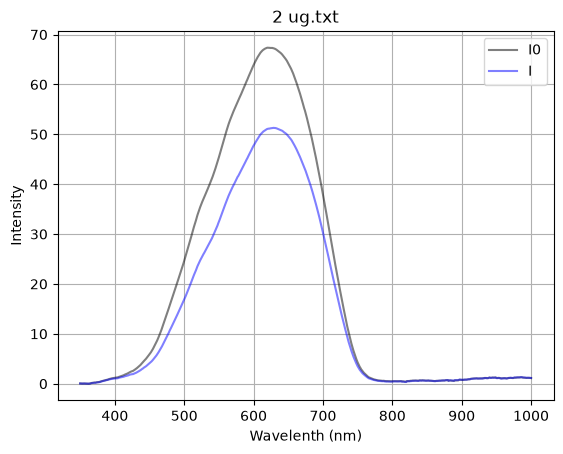

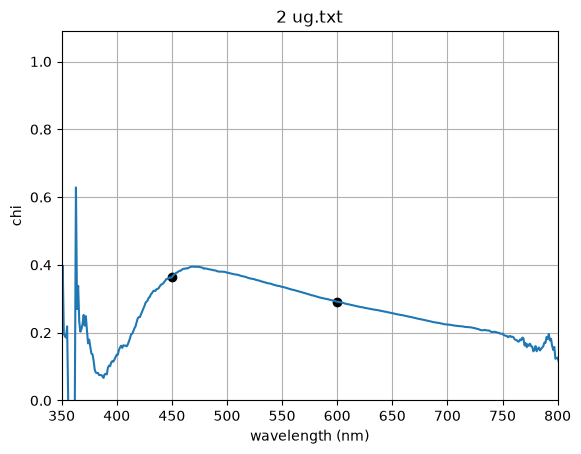

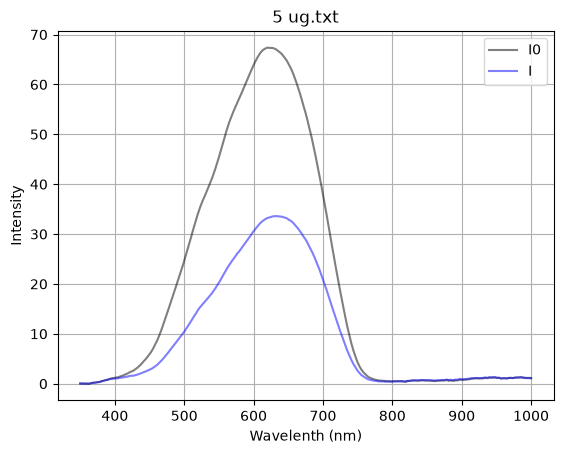

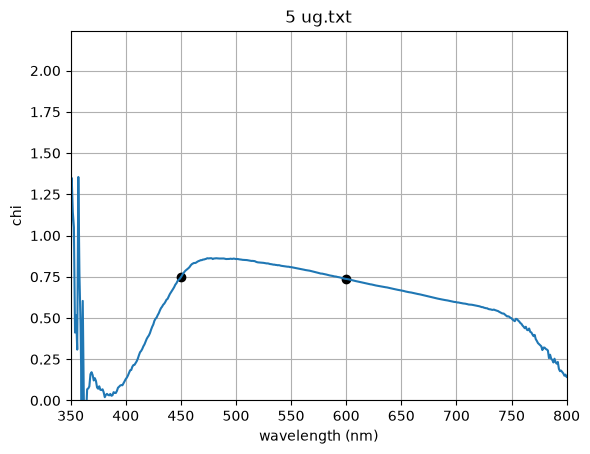

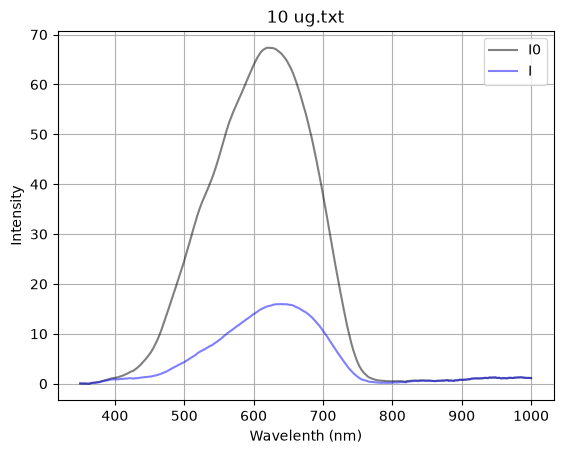

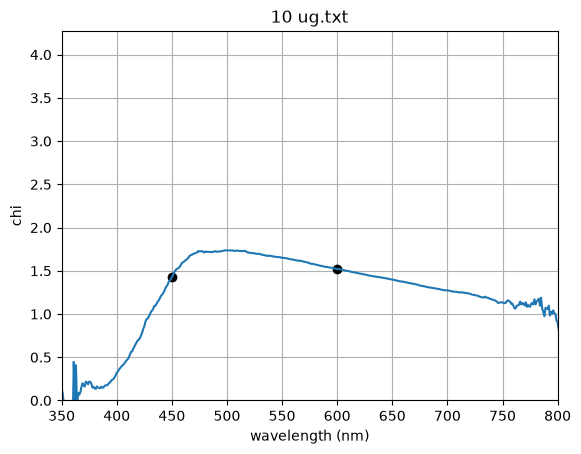

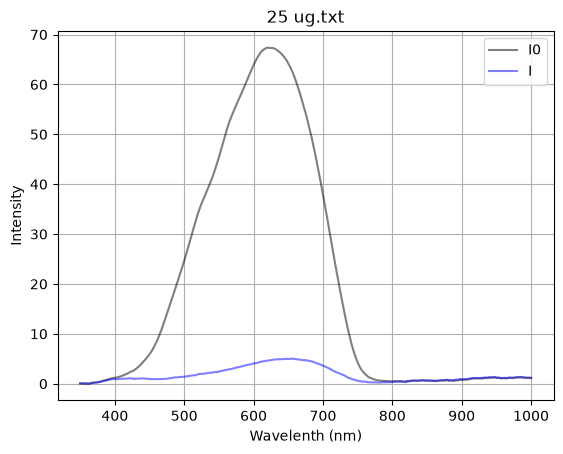

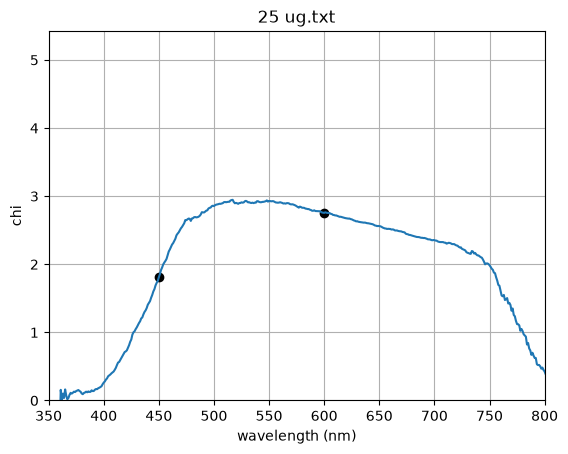

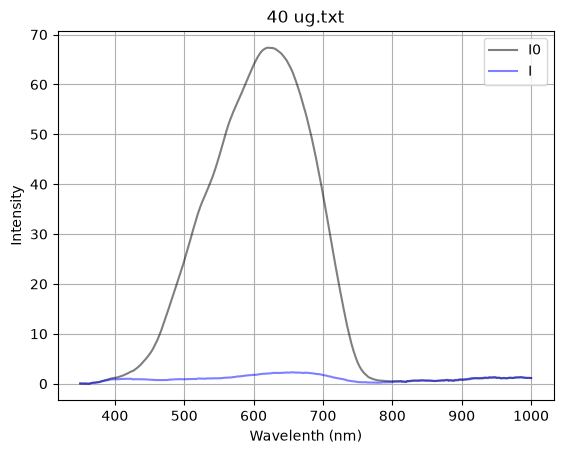

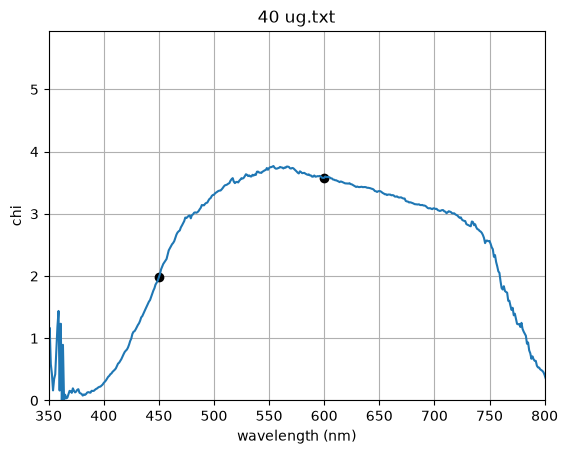

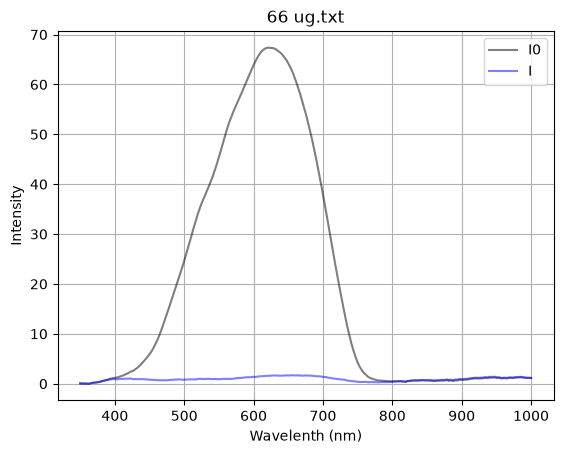

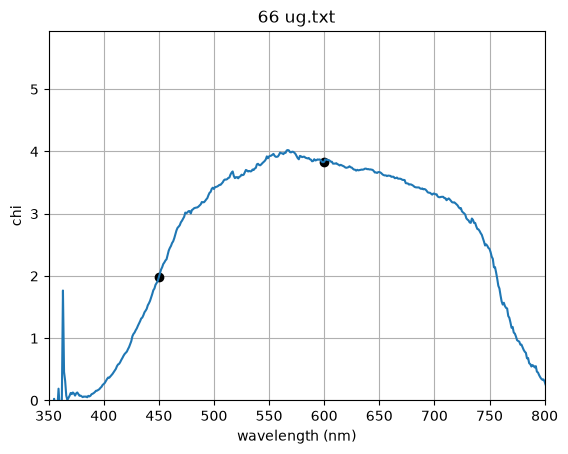

In [3]:
# Load in the blank, and check indices
lambda_nm, I0_raw = IS.get_spectrum(spectrum_folder+'/Blank.txt')
I_450 = 100; print('lambda_450 = ',lambda_nm[I_450])
I_600 = 250; print('lambda_600 = ',lambda_nm[I_600])

# Preallocate arrays
# chi_observed = np.zeros((number_of_loadings,2))
chi_range_450 = np.zeros(number_of_loadings)
chi_range_600 = np.zeros(number_of_loadings)

# Get the chi-values
for i in range(number_of_loadings):
    
    # Extract the spectrum for this item in the list
    spectrum_filename = spectrum_list[i]
    lambda_nm, I_raw = IS.get_spectrum(spectrum_folder+spectrum_filename)
    
    # Smooth and shift
    I, I0 = IS.smooth_and_shift(I_raw,I0_raw)
    
    # Get observed chi
    chi = IS.get_chi_obs(I,I0,lambda_nm, title=spectrum_filename)
    
    # Save chi values at lambda1 and lambda2
    chi_range_450[i] = chi[I_450]
    chi_range_600[i] = chi[I_600]

# Specify subsets of the calibration dataset to use (set to 0 and -1 for all)
subset_start = 0
subset_stop = -1
chi_range_450 = chi_range_450[subset_start:subset_stop]; print(chi_range_450)
chi_range_600 = chi_range_600[subset_start:subset_stop]; print(chi_range_600)
number_of_loadings = np.size(chi_range_450)

# Loading values on samples and their optical depths
L_range = np.array([2, 5, 10, 25, 40, 66])/2 # This is in micrograms
L_range = L_range[subset_start:subset_stop]

# Double-checking
print('Length of L_range = ', len(L_range))
print('Number of loadings = ', number_of_loadings)
if len(L_range) != number_of_loadings:
    print('inconsistency')
    np.sqrt(-1)

### Using Tom's theory with the extra B^-1
The cell below uses Tom's formulas.

In [4]:
# dchi/dL
dchi_dL_450 = np.diff(chi_range_450)/np.diff(L_range)
dchi_dL_600 = np.diff(chi_range_600)/np.diff(L_range)

# beta (scaled by k)
this_difference = 0
betabar_450 = dchi_dL_450[this_difference]; print('betabar_450 = ', betabar_450)
betabar_600 = dchi_dL_600[this_difference]; print('betabar_600 = ', betabar_600)

# AAE
AAE = (-np.log(betabar_450/betabar_600)/np.log(450/600))
print('AAE_std from chi slopes = ', AAE)

# Calculating the optical depth based on these loadings and betas
tau_range_450 = L_range*betabar_450
tau_range_600 = L_range*betabar_600


betabar_450 =  0.2556389242433743
betabar_600 =  0.29693215350346097
AAE_std from chi slopes =  -0.5204970729206025


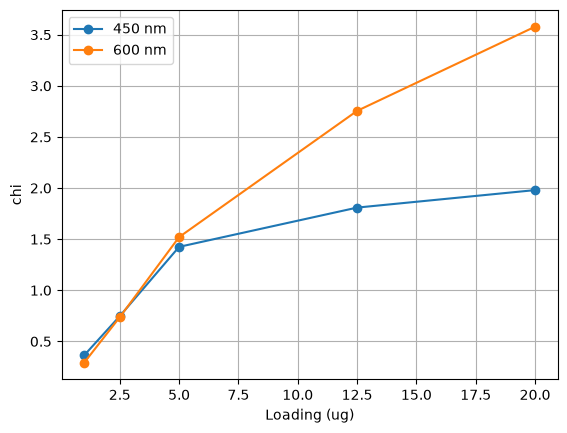

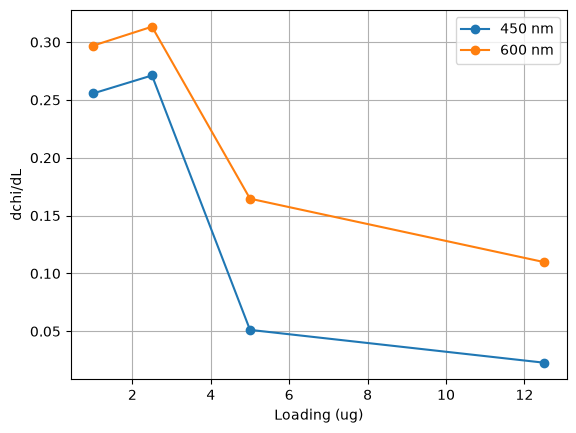

In [5]:
# Let's take a look at chi as a function of loading
plt.figure()
plt.plot(L_range,chi_range_450,marker='o',label='450 nm')
plt.plot(L_range,chi_range_600,marker='o',label='600 nm')
plt.xlabel('Loading (ug)')
plt.ylabel('chi')
plt.legend()
plt.grid(True)

# Let's take a look at dchi/dL as a function of loading
plt.figure()
plt.plot(L_range[0:-1],dchi_dL_450,marker='o',label='450 nm')
plt.plot(L_range[0:-1],dchi_dL_600,marker='o',label='600 nm')
plt.xlabel('Loading (ug)')
plt.ylabel('dchi/dL')
plt.legend()
plt.grid(True)

best R_450 =  0.99
best R_600 =  0.6803131313131313


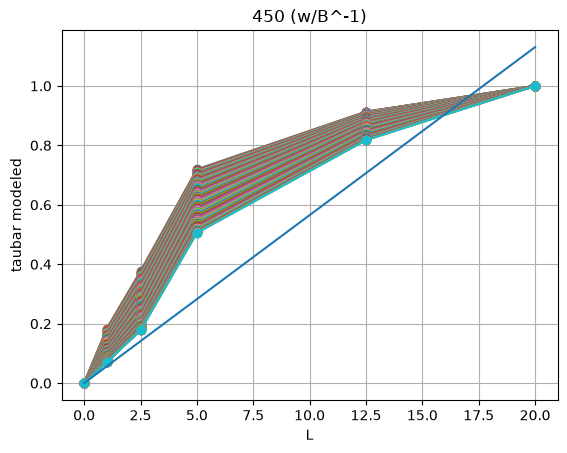

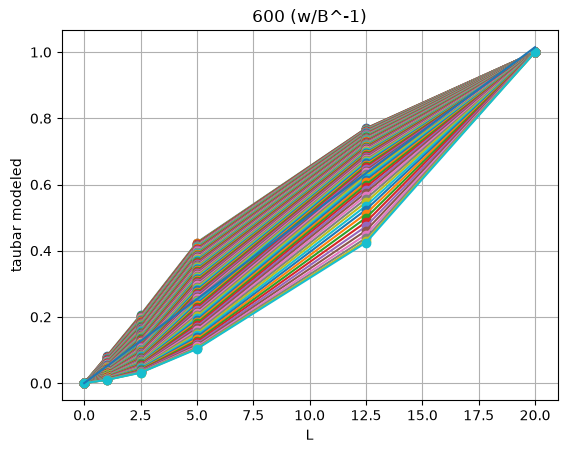

In [6]:
# Now we're looking for the best R-values, which means R-values that produce tau_modeled as close
# to a straight line as possible
L_range_extended = np.append(0,L_range)
weights = np.ones(np.shape(L_range_extended)); weights[0] = 100
n_R_tries = 100
R_450_testrange = R_600_testrange = np.linspace(.001, .99, n_R_tries)
penalty = np.zeros(n_R_tries)

p_450_list = []
plt.figure()
for j in range(len(R_450_testrange)):
    R_450_test = R_450_testrange[j]
    taubar_450_modeled = 2*(1+R_450_test)/(1-R_450_test)*IS.get_f(chi_range_450,R_450_test)
    # print(j,taubar_450_modeled[-1])
    taubar_450_modeled /= taubar_450_modeled[-1]
    taubar_450_modeled = np.append(0,taubar_450_modeled)
    plt.plot(L_range_extended,taubar_450_modeled,'-o',label=str(R_450_test))
    # plt.legend()
    plt.ylabel('taubar modeled')
    plt.xlabel('L')
    plt.grid(True)
    plt.title('450 (w/B^-1)')
    p_450 = np.polyfit(L_range_extended,taubar_450_modeled,1,w=weights)
    taubar_450_bestfit = np.polyval(p_450,L_range_extended)
    penalty[j] = np.sum((taubar_450_bestfit-taubar_450_modeled)**2)
    p_450_list = np.append(p_450_list,p_450)
jbest = np.argmin(penalty)
R_450_best = R_450_testrange[jbest]
print('best R_450 = ', R_450_best)
p_450_list = np.reshape(p_450_list,(n_R_tries,2))
p_450_bestfit = p_450_list[jbest]
taubar_450_bestfit = np.polyval(p_450_bestfit,L_range_extended)
plt.plot(L_range_extended,taubar_450_bestfit)

p_600_list = []
plt.figure()
for j in range(len(R_600_testrange)):
    R_600_test = R_600_testrange[j]
    taubar_600_modeled = 2*(1+R_600_test)/(1-R_600_test)*IS.get_f(chi_range_600,R_600_test)
    # print(j,taubar_600_modeled[-1])
    taubar_600_modeled /= taubar_600_modeled[-1]
    taubar_600_modeled = np.append(0,taubar_600_modeled)
    plt.plot(L_range_extended,taubar_600_modeled,'-o',label=str(R_600_test))
    plt.ylabel('taubar modeled')
    plt.xlabel('L')
    plt.grid(True)
    # plt.legend()
    plt.title('600 (w/B^-1)')
    p_600 = np.polyfit(L_range_extended,taubar_600_modeled,1,w=weights)
    taubar_600_bestfit = np.polyval(p_600,L_range_extended)
    penalty[j] = np.sum((taubar_600_bestfit-taubar_600_modeled)**2)
    p_600_list = np.append(p_600_list,p_600)
jbest = np.argmin(penalty)
R_600_best = R_600_testrange[jbest]
print('best R_600 = ', R_600_best)
p_600_list = np.reshape(p_600_list,(n_R_tries,2))
p_600_bestfit = p_600_list[jbest]
taubar_600_bestfit = np.polyval(p_600_bestfit,L_range_extended)
plt.plot(L_range_extended,taubar_600_bestfit)

In [7]:
# # This is just a test that the inversion is correct
# print(chi_range_450)
# f_range_450 = IS.get_f(chi_range_450,R_450_best); print(f_range_450)
# chi_test = IS.get_chi_theory(f_range_450,R_450_best); print(chi_test)

In [8]:
# Saving parameters
parameter_filename = 'calibration III parameters from Ulyana ful (July 21, 2026).csv'
calibration_spectrum_folder = spectrum_folder
AAE_std = AAE
betabar_450_std = betabar_450
betabar_600_std = betabar_600
R_450_std = R_450_best
R_600_std = R_600_best

Save_parameter_flag = True
if Save_parameter_flag:

    print('Saving the parameter file ...')
    data = {
    "calibration_spectrum_folder": [calibration_spectrum_folder],
    "R_450_std": [R_450_std],
    "R_600_std": [R_600_std],
    "betabar_450_std": [betabar_450_std],
    "betabar_600_std": [betabar_600_std],
    "filtertype_std": [filtertype_std],
    "AAE_std": [AAE_std]
    }
    df = pd.DataFrame(data)
    
    # Display the DataFrame
    print(df)

    df.to_csv(parameter_filename, index=False)

Saving the parameter file ...
  calibration_spectrum_folder  R_450_std  R_600_std  betabar_450_std  \
0                 Ulyana ful/       0.99   0.680313         0.255639   

   betabar_600_std filtertype_std   AAE_std  
0         0.296932      millipore -0.520497  


In [9]:
# Now, pretending this is a retrieval ... we already have chi_range_450 and chi_range_600
chi_450_obs = chi_range_450
chi_600_obs = chi_range_600

f_450_obs = IS.get_f(chi_450_obs,R_450_std); print(f_450_obs)
f_600_obs = IS.get_f(chi_600_obs,R_600_std); print(f_600_obs)

# Reduced optical depths
taubar_450_obs = f_450_obs *2*(1+R_450_std)/(1-R_450_std)
taubar_600_obs = f_600_obs *2*(1+R_600_std)/(1-R_600_std)

# Get the AAE implied by these optical depths
AAE_obs = -np.log(taubar_450_obs/taubar_600_obs)/np.log(450/600)

# Assuming the standard's beta values, get equivalent loadings
L_450_equiv = taubar_450_obs/betabar_450_std
L_600_equiv = taubar_600_obs/betabar_600_std

# Report out
print('450')
for j in range(number_of_loadings):
    print('LAHM loading, fullerene-equivalent loading at 450, AAE = ', L_range[j], L_450_equiv[j], AAE_obs[j])
print('600')
# for j in range(number_of_loadings):
#     print('j, LAHM loading, fullerene-equivalent loading at 600 = ', j, L_range[j], L_600_equiv[j])



[0.00110113 0.00278995 0.00793177 0.01282041 0.01568258]
[0.03198604 0.1010124  0.30302078 0.82024592 1.22163515]
450
LAHM loading, fullerene-equivalent loading at 450, AAE =  1.0 1.7143346578421397 0.9209846363197641
LAHM loading, fullerene-equivalent loading at 450, AAE =  2.5 4.3436287049624625 0.15535253331057897
LAHM loading, fullerene-equivalent loading at 450, AAE =  5.0 12.348840133158943 -0.03133277572693022
LAHM loading, fullerene-equivalent loading at 450, AAE =  12.5 19.959890855479628 -1.8237286709275156
LAHM loading, fullerene-equivalent loading at 450, AAE =  20.0 24.41594177523992 -2.5079209602195447
600
